# Residual_Unet_3D_5K vs SOTA (kitedemo_4 single sample)

Compares your **Residual_Unet_3D_5K** model against SOTA depth models on one sample from `kitedemo_4`. Set `SAMPLE_ID` to choose the image.


In [1]:
%pip install torch torchvision transformers pillow matplotlib pandas



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F
import tensorflow as tf
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

from Models_Arch.ResidualUnet_3Dense_5Kernels import Residual_Unet_3D_5K

OUTPUT_DIR = Path("visuals")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_DIR = Path("kitedemo_4")
SAMPLE_ID = "000000"  # change this to another id (e.g., "000123")

LEFT_PATH = DATASET_DIR / f"{SAMPLE_ID}.left.jpg"
RIGHT_PATH = DATASET_DIR / f"{SAMPLE_ID}.right.jpg"
DEPTH_PATH = DATASET_DIR / f"{SAMPLE_ID}.left.depth.png"

# Residual model
MODEL_PATH = Path("Residual_Unet_3D_5K.keras")

# Resize to match training shape (W,H)
RESIZE_TO = (480, 256)

# Alignment option for fair comparison
ALIGN_TO_GT = True  # set False to compare absolute scales

MODEL_IDS = {
    "DPT-Large": "Intel/dpt-large",
    "Depth-Anything-V2-Small": "depth-anything/Depth-Anything-V2-Small-hf",
    "ZoeDepth-NK": "Intel/zoedepth-nyu-kitti",
}

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

for p in [LEFT_PATH, RIGHT_PATH, DEPTH_PATH, MODEL_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p.resolve()}")


/Users/ahmed_ali/.pyenv/versions/3.11.6/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


In [3]:
def load_rgb(path: Path, resize_to):
    img = Image.open(path).convert("RGB")
    img = img.resize(resize_to, Image.BILINEAR)
    return img


def load_depth(path: Path, resize_to):
    depth = Image.open(path)
    depth = depth.resize(resize_to, Image.BILINEAR)
    return np.array(depth).astype(np.float32)


def robust_minmax(arr: np.ndarray, valid_mask: np.ndarray):
    if not np.any(valid_mask):
        return 0.0, 1.0
    vals = arr[valid_mask]
    vmin = np.percentile(vals, 2)
    vmax = np.percentile(vals, 98)
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return float(vmin), float(vmax)


In [4]:
left_img = load_rgb(LEFT_PATH, RESIZE_TO)
right_img = load_rgb(RIGHT_PATH, RESIZE_TO)
gt_depth = load_depth(DEPTH_PATH, RESIZE_TO)

left_rgb = np.array(left_img)
right_rgb = np.array(right_img)

# Residual model was trained with cv2.imread (BGR). Convert RGB -> BGR.
left_bgr = left_rgb[..., ::-1]
right_bgr = right_rgb[..., ::-1]

print(f"Left shape: {left_rgb.shape}, Depth shape: {gt_depth.shape}")


Left shape: (256, 480, 3), Depth shape: (256, 480)


In [5]:
models = {}
for name, model_id in MODEL_IDS.items():
    print(f"Loading {name} ({model_id})...")
    processor = AutoImageProcessor.from_pretrained(model_id)
    model = AutoModelForDepthEstimation.from_pretrained(model_id).to(device)
    model.eval()
    models[name] = (processor, model)

print("Loading Residual_Unet_3D_5K...")
residual_model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={"Residual_Unet_3D_5K": Residual_Unet_3D_5K},
    compile=False,
)
residual_model.trainable = False
print(f"Loaded {len(models)} SOTA models + Residual_Unet_3D_5K")


Loading DPT-Large (Intel/dpt-large)...


Loading weights: 100%|██████████| 458/458 [00:00<00:00, 6832.77it/s]
[transformers] DPTForDepthEstimation LOAD REPORT from: Intel/dpt-large
Key                                                            | Status  | 
---------------------------------------------------------------+---------+-
neck.fusion_stage.layers.0.residual_layer1.convolution2.weight | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution2.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading Depth-Anything-V2-Small (depth-anything/Depth-Anything-V2-Small-hf)...


Loading weights: 100%|██████████| 287/287 [00:00<00:00, 5800.08it/s]


Loading ZoeDepth-NK (Intel/zoedepth-nyu-kitti)...


Loading weights: 100%|██████████| 647/647 [00:00<00:00, 9241.83it/s]


Loading Residual_Unet_3D_5K...


2026-06-02 00:33:07.834191: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-06-02 00:33:07.834867: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-02 00:33:07.834871: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-02 00:33:07.834916: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-02 00:33:07.835511: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Loaded 3 SOTA models + Residual_Unet_3D_5K


In [6]:
def predict_depth_sota(model_bundle, pil_image: Image.Image) -> np.ndarray:
    processor, model = model_bundle
    inputs = processor(images=pil_image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        pred = model(**inputs).predicted_depth
        pred = F.interpolate(
            pred.unsqueeze(1),
            size=pil_image.size[::-1],
            mode="bicubic",
            align_corners=False,
        ).squeeze().cpu().numpy().astype(np.float32)
    return pred


def predict_residual(model, left: np.ndarray, right: np.ndarray) -> np.ndarray:
    left_in = np.asarray(left, dtype=np.float32)[None, ...]
    right_in = np.asarray(right, dtype=np.float32)[None, ...]
    pred = model.predict([left_in, right_in], verbose=0)
    return np.squeeze(pred).astype(np.float32)


def scale_align_prediction(pred: np.ndarray, gt: np.ndarray, valid_mask: np.ndarray) -> np.ndarray:
    pred_valid = pred[valid_mask]
    gt_valid = gt[valid_mask]
    pred_med = np.median(pred_valid)
    gt_med = np.median(gt_valid)
    if pred_med <= 0:
        return pred
    return pred * (gt_med / pred_med)


def depth_metrics(pred: np.ndarray, gt: np.ndarray, valid_mask: np.ndarray):
    p = pred[valid_mask]
    g = gt[valid_mask]
    abs_rel = float(np.mean(np.abs(p - g) / np.clip(g, 1e-6, None)))
    rmse = float(np.sqrt(np.mean((p - g) ** 2)))
    return {"AbsRel": abs_rel, "RMSE": rmse}


In [7]:
valid = gt_depth > 0

# Residual prediction
pred_residual = predict_residual(residual_model, left_bgr, right_bgr)
if ALIGN_TO_GT:
    pred_residual = scale_align_prediction(pred_residual, gt_depth, valid)
metrics_res = depth_metrics(pred_residual, gt_depth, valid)

rows = [{"model": "Residual_Unet_3D_5K", **metrics_res}]
preds_for_plot = {"Residual_Unet_3D_5K": pred_residual}

for model_name, bundle in models.items():
    pred = predict_depth_sota(bundle, left_img)
    if ALIGN_TO_GT:
        pred = scale_align_prediction(pred, gt_depth, valid)
    metrics = depth_metrics(pred, gt_depth, valid)
    rows.append({"model": model_name, **metrics})
    preds_for_plot[model_name] = pred


/Users/ahmed_ali/.pyenv/versions/3.11.6/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['first_image', 'second_image']. Received: the structure of inputs=('*', '*')
  warnings.warn(
2026-06-02 00:33:09.220963: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


In [8]:
df = pd.DataFrame(rows)
display(df)

csv_path = OUTPUT_DIR / f"residual_vs_sota_kitedemo_{SAMPLE_ID}.csv"
df.to_csv(csv_path, index=False)
print(f"Saved metrics to: {csv_path.resolve()}")


,model,AbsRel,RMSE
0,Residual_Unet_3D_5K,0.042070,866.926636
1,DPT-Large,0.229204,3685.791992
2,Depth-Anything-V2-Small,0.380007,5831.849609
3,ZoeDepth-NK,0.125392,2082.457275


Saved metrics to: /Users/ahmed_ali/Downloads/DeepView3D-main/visuals/residual_vs_sota_kitedemo_000000.csv


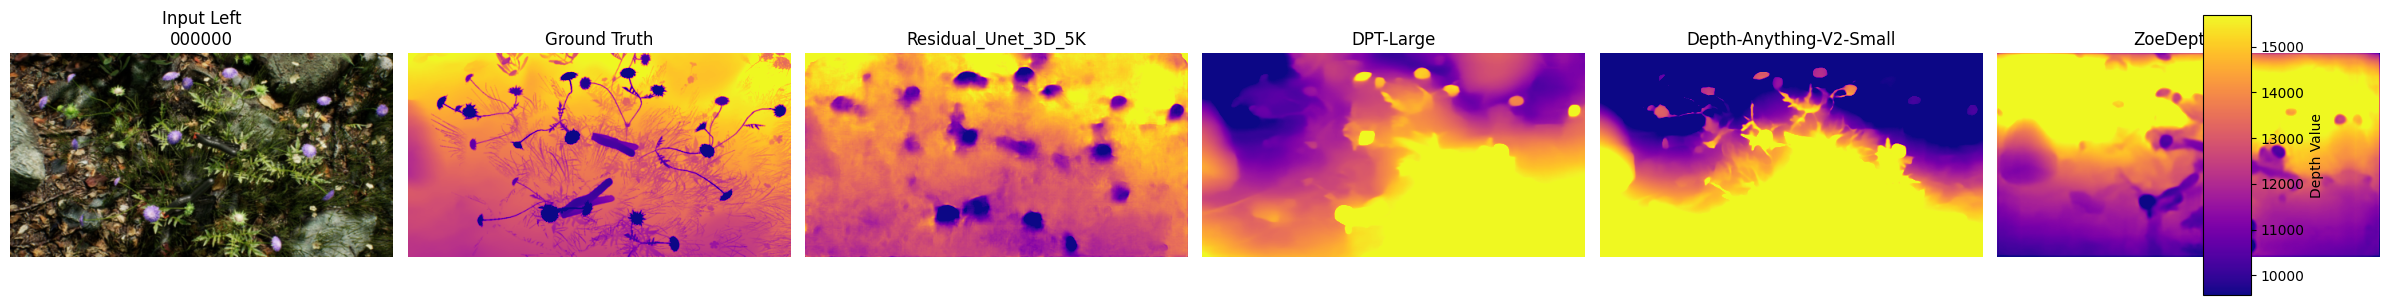

Saved comparison image to: /Users/ahmed_ali/Downloads/DeepView3D-main/visuals/residual_vs_sota_kitedemo_000000.png


In [ ]:
vmin, vmax = robust_minmax(gt_depth, valid)
num_cols = 2 + len(preds_for_plot)
fig, axes = plt.subplots(1, num_cols, figsize=(4 * num_cols, 4))

axes[0].imshow(left_img)
axes[0].set_title(f"Input Left\n{SAMPLE_ID}")
axes[0].axis("off")

# scalar mappable for consistent colorbars
sm = plt.cm.ScalarMappable(cmap="plasma", norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

axes[1].imshow(gt_depth, cmap="plasma", vmin=vmin, vmax=vmax)
axes[1].set_title("Ground Truth")
axes[1].axis("off")
fig.colorbar(sm, ax=axes[1], fraction=0.046, pad=0.02, label="Depth Value")

for col_idx, (name, pred) in enumerate(preds_for_plot.items(), start=2):
    axes[col_idx].imshow(pred, cmap="plasma", vmin=vmin, vmax=vmax)
    axes[col_idx].set_title(name)
    axes[col_idx].axis("off")
    fig.colorbar(sm, ax=axes[col_idx], fraction=0.046, pad=0.02)

plt.tight_layout()
out_path = OUTPUT_DIR / f"residual_vs_sota_kitedemo_{SAMPLE_ID}.png"
fig.savefig(out_path, dpi=180, bbox_inches="tight")

plt.show()
print(f"Saved comparison image to: {out_path.resolve()}")
